In [1]:
# Credit Card Fraud Detector
# Detect fraudulent transactions in real time
# Tech: Rendom Forest, imbalance data handling

In [2]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.metrics import roc_curve
import joblib

In [3]:
# Load and Imspact Dataset

df = pd.read_csv('creditcard.csv')
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
# Check and Remove missing rows

print(df.isnull().sum()[df.isnull().sum() > 0])
df = df.dropna()
print(df.shape)

V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64
(11958, 31)


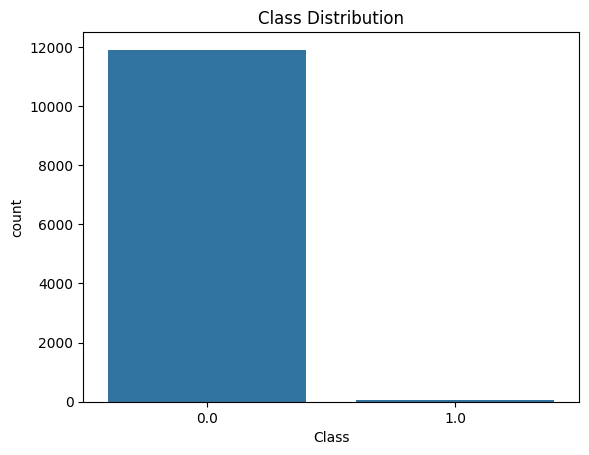

In [5]:
# Exploratory Data Analysis

# Plot class distribution

sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

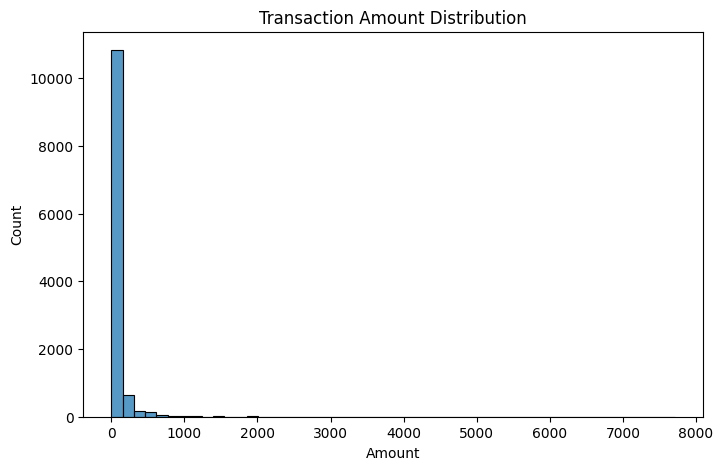

In [6]:
# Plot transaction amouonts

plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

In [7]:
# Comparing Fraud vs Non-fraud amounts
print(df.groupby('Class')['Amount'].describe())

         count       mean         std  min     25%    50%      75%      max
Class                                                                      
0.0    11906.0  62.198127  177.379105  0.0  5.2925  15.95  50.0000  7712.43
1.0       52.0  97.724808  321.188775  0.0  1.0000   1.00   1.7725  1809.68


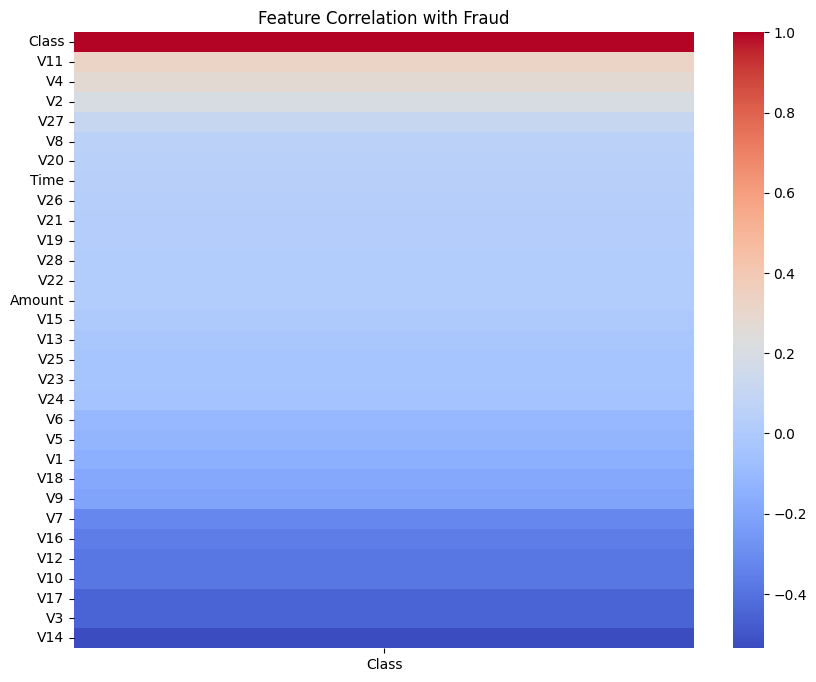

In [8]:
# Check Correlation with Fraud

corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr[['Class']].sort_values(by='Class', ascending=False),
    annot=False,
    cmap='coolwarm'
)
plt.title('Feature Correlation with Fraud')
plt.show()

In [9]:
#Data Preprocessing

# Separating Features and Target

X = df.drop('Class', axis=1)
y = df['Class']

# Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Scaling

sc = StandardScaler()
X_train[['Time', 'Amount']] = sc.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = sc.transform(X_test[['Time', 'Amount']])

In [10]:
# Train Random Forest model

rf = RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = 1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=1, random_state=42)

In [11]:
# Prediction

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [12]:
# Model Evaluation

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9991638795986622
Precision: 1.0
Recall   : 0.8
F1 Score : 0.8888888888888888
ROC AUC  : 0.9481318219983207

Confusion Matrix
[[2382    0]
 [   2    8]]

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2382
         1.0       1.00      0.80      0.89        10

    accuracy                           1.00      2392
   macro avg       1.00      0.90      0.94      2392
weighted avg       1.00      1.00      1.00      2392



In [13]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance.head(15))

   Feature  Importance
12     V12    0.172926
14     V14    0.158616
17     V17    0.117107
11     V11    0.093880
10     V10    0.079147
4       V4    0.056194
16     V16    0.055013
3       V3    0.051866
9       V9    0.032798
18     V18    0.016143
29  Amount    0.014388
26     V26    0.013546
6       V6    0.012843
19     V19    0.011219
0     Time    0.010786


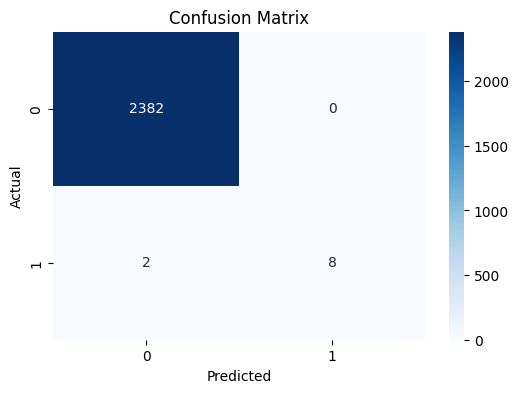

In [14]:
# Visualizations

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

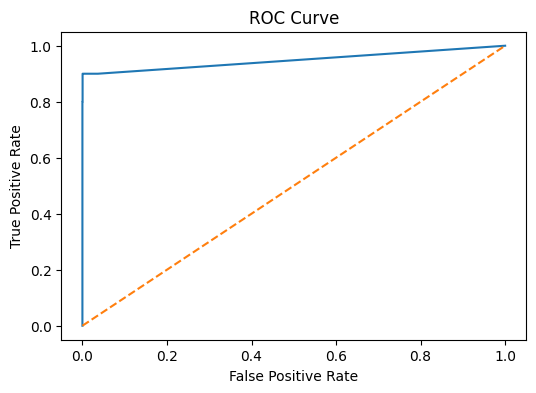

In [15]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [18]:
# Saving the trained model

joblib.dump(rf,"fraud_detector.pkl")

['fraud_detector.pkl']